# Connectivity (trial-shuffle xcorr)

Exploratory visualization of **functional-cluster–partner** coupling from
`run_xcorr_pair_permutation.py` outputs:

- Input xcorr: main checkout `insula/results/{Task}(bipolar)/…/xcorr/*_perm.{csv,nc}`
- Focus electrodes: this worktree NMF `results/nmf/channel_assignments.csv`
  (`sustained_ramping` / `intermediate` / `sensory_transient`)
- Partner ROI/coords: Hammers `*_coord.csv` under main `insula/results/{Task}(bipolar)(hammers)/…/HGA/`
- Logic adapted from `vizpub/fig2_legacy.ipynb` Connectivity section

Figures are shown inline (no export required). Style follows
[`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from IPython.display import display
from mne_bids import BIDSPath
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import hga_results_dir, nmf_results_dir

from src.paths import img_dir, save_svg
IMG_DIR = img_dir('connectivity')


In [2]:
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

fontdict = dict(fontsize=7)
fontsize = 7

red = "#A9373B"   # sustained_ramping
gold = "#C4A35A"  # intermediate
blue = "#2369BD"  # sensory_transient
orange = "#CC8963"
green = "#009944"

# Main checkout has Hammers coords + xcorr; this worktree has NMF.
LOCAL_RESULTS = Path("../results")
MAIN_RESULTS = Path("/hpc/group/coganlab/nanlinshi/insula/results")
# Prefer main for Hammers coords + xcorr (local results/hga has time only).
RESULTS_ROOTS = [MAIN_RESULTS, LOCAL_RESULTS]
RECON_DIR = "/cwork/ns458/ECoG_Recon/"
# Concat multi-phase NMF, post-onset crop, k=3 (same as functional_hga)
NMF_DIR = nmf_results_dir()  # canonical published assignments

FOCUS_CLUSTERS = ["sustained_ramping", "intermediate", "sensory_transient"]
CLUSTER_LABELS = {
    "sustained_ramping": "sustained",
    "intermediate": "intermediate",
    "sensory_transient": "sensory",
}
CLUSTER_COLORS = {
    "sustained_ramping": red,
    "intermediate": gold,
    "sensory_transient": blue,
}
CLUSTER_CMAPS = {
    "sustained_ramping": "Reds",
    "intermediate": "YlOrBr",
    "sensory_transient": "Blues",
}


def resolve_results_dir(rel: str) -> Path | None:
    """Return the first existing results/{rel} across RESULTS_ROOTS."""
    for root in RESULTS_ROOTS:
        path = root / rel
        if path.exists():
            return path
    return None


## Config

`TASK_ROOTS` maps the analysis task name to the on-disk results folder.
Phoneme xcorr outputs live under `PhonemeSequencing(bipolar)` (BIDS task name).

Focus = NMF functional clusters (this worktree `results/nmf`).
Partner coords / xcorr are read from the **main** checkout
`/hpc/group/coganlab/nanlinshi/insula/results`, with local `../results` as fallback.


In [3]:
REF = "bipolar"
ATLAS = "hammers"
DESCRIPTION = "Repeat"
BAND = "highgamma"

# analysis label -> results/{root}(bipolar)
TASK_ROOTS = {
    "LexicalDelay": "LexicalDelay",
    "LexicalNoDelay": "LexicalNoDelay",
    "PhonemeSequence": "PhonemeSequencing",  # BIDS task name on disk
    "PictureNaming": "PictureNaming",
    "SentenceRep": "SentenceRep",
}

# HGA coord packaging uses the analysis task names
HGA_TASKS = [
    "LexicalDelay",
    "LexicalNoDelay",
    "PhonemeSequence",
    "PictureNaming",
    "SentenceRep",
]

MIN_PEAK_VAL = 0.05
MAX_ABS_LAG_S = 0.5
PHASES = ["stimulus", "delay", "go", "response"]

EXCLUDE_ROIS = {"Intersection", "LinG", "OccS", "CollatAnt", "Central", "Unknown"}
ROI_MAP = {"MFGs": "MFG", "IFGs": "IFG", "SFGs": "SFG", "OFCs": "OFC"}


## Load channel metadata

- Hammers `*_coord.csv` from `{Task}(bipolar)(hammers)/…/HGA/` (main checkout)
- NMF `channel_assignments.csv` → `functional_cluster` (for focus)


In [4]:
coord_paths = []
# Coords live under {Task}(bipolar)(hammers)/…/HGA/*_coord.csv in the main
# checkout. Local results/hga/ only has *_time.csv (no coords).
for t in HGA_TASKS:
    found = False
    candidate_roots = []
    for root in RESULTS_ROOTS:
        candidate_roots.append(root / f"{t}({REF})({ATLAS})")
        candidate_roots.append(root / "hga" / t)
    for task_root in candidate_roots:
        if not task_root.exists():
            continue
        matched = BIDSPath(
            root=str(task_root),
            datatype="HGA",
            suffix="coord",
            description=DESCRIPTION,
            check=False,
        ).match()
        if not matched:
            continue
        print(f"[HGA] {t} ← {task_root} ({len(matched)} coords)")
        coord_paths.extend(matched)
        found = True
        break
    if not found:
        print(f"[skip HGA] no coord CSVs for {t} in {RESULTS_ROOTS}")

if not coord_paths:
    raise FileNotFoundError(
        f"No coord CSVs under {{Task}}({REF})({ATLAS})/HGA/ in {RESULTS_ROOTS}"
    )

coords = pd.concat(
    [pd.read_csv(p) for p in tqdm(coord_paths, desc="load coords")],
    ignore_index=True,
)

# Hammers ROI groupings (same as vizpub/fig2.ipynb)
coords.loc[coords.roi == "PrG", "roi"] = "SMC"
coords.loc[coords.roi == "PoG", "roi"] = "SMC"
coords.loc[coords.roi == "Subcentral", "roi"] = "SMC"
coords.loc[coords.roi == "STGp", "roi"] = "STG"
coords.loc[coords.roi == "STGa", "roi"] = "STG"
coords.loc[coords.roi == "HG", "roi"] = "STG"

channel_meta = (
    coords[["channel", "roi", "hemi", "x", "y", "z"]]
    .dropna(subset=["channel", "roi"])
    .groupby("channel", as_index=False)
    .first()
)

assignments = pd.read_csv(NMF_DIR / "channel_assignments.csv")
assign_map = (
    assignments.loc[assignments["functional_cluster"].isin(FOCUS_CLUSTERS)]
    .drop_duplicates(subset=["channel"], keep="first")
    .set_index("channel")["functional_cluster"]
)
channel_meta["functional_cluster"] = channel_meta["channel"].map(assign_map)

exclude_chn = []
for root in RESULTS_ROOTS:
    exclude_path = root / "exlude_insula.csv"
    if not exclude_path.exists():
        continue
    exclude_df = pd.read_csv(exclude_path, index_col=0)
    exclude_chn = [
        electrode
        for item in exclude_df.Exclude.dropna()
        for electrode in eval(item)
    ]
    channel_meta = channel_meta[~channel_meta.channel.isin(exclude_chn)].copy()
    print(f"[exclude] {exclude_path} ({len(exclude_chn)} channels)")
    break

n_assigned = channel_meta["functional_cluster"].notna().sum()
print(f"Channels: {len(channel_meta)} | NMF-assigned: {n_assigned}")
for c in FOCUS_CLUSTERS:
    print(f"  {CLUSTER_LABELS[c]}: {(channel_meta.functional_cluster == c).sum()}")
channel_meta.head()


[HGA] LexicalDelay ← /hpc/group/coganlab/nanlinshi/insula/results/LexicalDelay(bipolar)(hammers) (196 coords)
[HGA] LexicalNoDelay ← /hpc/group/coganlab/nanlinshi/insula/results/LexicalNoDelay(bipolar)(hammers) (44 coords)
[HGA] PhonemeSequence ← /hpc/group/coganlab/nanlinshi/insula/results/PhonemeSequence(bipolar)(hammers) (184 coords)
[HGA] PictureNaming ← /hpc/group/coganlab/nanlinshi/insula/results/PictureNaming(bipolar)(hammers) (297 coords)
[skip HGA] no coord CSVs for SentenceRep in [PosixPath('/hpc/group/coganlab/nanlinshi/insula/results'), PosixPath('../results')]


load coords:   0%|          | 0/721 [00:00<?, ?it/s]

Channels: 13933 | NMF-assigned: 266
  sustained: 97
  intermediate: 134
  sensory: 35


,channel,roi,hemi,x,y,z,functional_cluster
0,D0019_RIIH1-2,LinG,R,8.41703,-44.3481,-20.64296,NaN
1,D0019_RIIH2-3,LinG,R,4.62597,-55.4648,-17.93574,NaN
2,D0019_RIIH3-4,LinG,R,4.06682,-64.4239,-15.98172,NaN
3,D0019_RIIH4-5,LinG–Cun,R,5.34089,-73.6314,-12.22795,NaN
4,D0019_RLOS1-2,AG,R,52.64330,-39.8362,33.99210,NaN


## Load xcorr permutation results

Load cluster tables (`*_perm.csv`) for all tasks/phases. Waveform NetCDF files
are loaded lazily when extracting peak lag/value.

In [5]:
all_clusters = []

for task_name, disk_root in TASK_ROOTS.items():
    results_root = resolve_results_dir(f"{disk_root}({REF})")
    if results_root is None:
        print(f"[skip] missing {disk_root}({REF}) in {RESULTS_ROOTS}")
        continue

    base = BIDSPath(
        root=str(results_root),
        datatype="xcorr",
        recording=BAND,
        description=DESCRIPTION,
        suffix="perm",
        check=False,
    )
    csv_paths = base.copy().update(extension=".csv").match()
    print(f"[{task_name}] root={results_root}  csv={len(csv_paths)}")

    for p in csv_paths:
        df = pd.read_csv(p.fpath)
        df["task"] = task_name
        df["phase"] = p.processing
        df["description"] = p.description
        df["file"] = str(p.fpath)
        all_clusters.append(df)

if not all_clusters:
    raise FileNotFoundError(f"No *_perm.csv files found under {RESULTS_ROOTS}")

clusters_df = pd.concat(all_clusters, ignore_index=True)
print(f"Total cluster rows: {len(clusters_df)}")
print(clusters_df.groupby(["task", "phase"]).size().unstack(fill_value=0))
clusters_df.head()


[LexicalDelay] root=/hpc/group/coganlab/nanlinshi/insula/results/LexicalDelay(bipolar)  csv=205
[LexicalNoDelay] root=/hpc/group/coganlab/nanlinshi/insula/results/LexicalNoDelay(bipolar)  csv=45
[PhonemeSequence] root=/hpc/group/coganlab/nanlinshi/insula/results/PhonemeSequencing(bipolar)  csv=188
[PictureNaming] root=/hpc/group/coganlab/nanlinshi/insula/results/PictureNaming(bipolar)  csv=0
[SentenceRep] root=/hpc/group/coganlab/nanlinshi/insula/results/SentenceRep(bipolar)  csv=62
Total cluster rows: 18034
phase            Delay    Go  Response  Stimulus
task                                            
LexicalDelay      1406  1352      2379      1326
LexicalNoDelay       0     0       752       440
PhonemeSequence    756   948      1415       865
SentenceRep        136    19      6089       151


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_546726/2373766425.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clusters_df = pd.concat(all_clusters, ignore_index=True)


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,description,file
0,18,D0023_RMSF6-7,D0023_RPIF2-3,0.046875,0.101562,0.086353,0.047952,True,LexicalDelay,Delay,Repeat,/hpc/group/coganlab/nanlinshi/insula/results/L...
1,13,D0023_RPIF9-10,D0023_R2MF8-9,-0.078125,-0.015625,0.111508,0.040959,True,LexicalDelay,Go,Repeat,/hpc/group/coganlab/nanlinshi/insula/results/L...
2,26,D0023_RPMF12-13,D0023_R2MF10-11,0.023438,0.109375,0.212033,0.006993,True,LexicalDelay,Go,Repeat,/hpc/group/coganlab/nanlinshi/insula/results/L...
3,28,D0023_RPMF12-13,D0023_R2MF9-10,-0.171875,-0.093750,0.107221,0.042957,True,LexicalDelay,Go,Repeat,/hpc/group/coganlab/nanlinshi/insula/results/L...
4,37,D0023_RPMF12-13,D0023_RPMF1-2,-0.250000,-0.179688,0.103120,0.047952,True,LexicalDelay,Go,Repeat,/hpc/group/coganlab/nanlinshi/insula/results/L...


## Merge ROI + functional-cluster labels onto significant clusters

Anatomical `*_roi` labels partners; `*_cluster` marks NMF focus membership.


In [6]:
sig_roi_df = (
    clusters_df.loc[clusters_df["significant"] == True]
    .copy()
    .merge(
        channel_meta.rename(
            columns={
                "channel": "source_channel",
                "roi": "source_roi",
                "hemi": "source_hemi",
                "x": "source_x",
                "y": "source_y",
                "z": "source_z",
                "functional_cluster": "source_cluster",
            }
        ),
        on="source_channel",
        how="left",
    )
    .merge(
        channel_meta.rename(
            columns={
                "channel": "target_channel",
                "roi": "target_roi",
                "hemi": "target_hemi",
                "x": "target_x",
                "y": "target_y",
                "z": "target_z",
                "functional_cluster": "target_cluster",
            }
        ),
        on="target_channel",
        how="left",
    )
)

print("sig rows:", len(sig_roi_df))
print("missing source_roi:", sig_roi_df["source_roi"].isna().sum())
print("missing target_roi:", sig_roi_df["target_roi"].isna().sum())
print(
    "NMF-assigned ends:",
    int(sig_roi_df["source_cluster"].notna().sum()),
    "(source) /",
    int(sig_roi_df["target_cluster"].notna().sum()),
    "(target)",
)
sig_roi_df.head()


sig rows: 18034
missing source_roi: 959
missing target_roi: 959
NMF-assigned ends: 484 (source) / 719 (target)


,pair_idx,source_channel,target_channel,lag_start_s,lag_end_s,mass,p_value,significant,task,phase,...,source_x,source_y,source_z,source_cluster,target_roi,target_hemi,target_x,target_y,target_z,target_cluster
0,18,D0023_RMSF6-7,D0023_RPIF2-3,0.046875,0.101562,0.086353,0.047952,True,LexicalDelay,Delay,...,15.5138,35.3361,21.1440,NaN,SMG,R,41.62430,-11.54200,-1.6901,NaN
1,13,D0023_RPIF9-10,D0023_R2MF8-9,-0.078125,-0.015625,0.111508,0.040959,True,LexicalDelay,Go,...,66.9825,-15.8252,2.2064,NaN,SMC,R,34.77700,9.01466,19.9182,NaN
2,26,D0023_RPMF12-13,D0023_R2MF10-11,0.023438,0.109375,0.212033,0.006993,True,LexicalDelay,Go,...,51.3652,-7.7959,20.7479,NaN,SMC,R,42.41840,8.79105,19.3140,NaN
3,28,D0023_RPMF12-13,D0023_R2MF9-10,-0.171875,-0.093750,0.107221,0.042957,True,LexicalDelay,Go,...,51.3652,-7.7959,20.7479,NaN,SMC,R,38.68610,8.81294,19.5575,NaN
4,37,D0023_RPMF12-13,D0023_RPMF1-2,-0.250000,-0.179688,0.103120,0.047952,True,LexicalDelay,Go,...,51.3652,-7.7959,20.7479,NaN,CG,R,8.00588,-1.51500,21.8557,NaN


## Extract peak lag / strength inside each significant cluster

For each significant lag-cluster, load the matching `*_perm.nc` pair curve and
take the peak within the cluster window.

In [7]:
ds_cache = {}


def get_ds(nc_file: str):
    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)
    return ds_cache[nc_file]


sig = sig_roi_df.copy()
sig["nc_file"] = sig["file"].apply(lambda x: str(Path(x).with_suffix(".nc")))

peak_rows = []
n_skip_pair_idx = 0
n_skip_empty_window = 0
n_skip_all_nan = 0
n_skip_missing_nc = 0

for _, row in tqdm(sig.iterrows(), total=len(sig), desc="extract peaks"):
    nc_file = row["nc_file"]
    if not Path(nc_file).exists():
        n_skip_missing_nc += 1
        continue

    pair_idx = int(row["pair_idx"])
    lag_start = float(row["lag_start_s"])
    lag_end = float(row["lag_end_s"])

    ds = get_ds(nc_file)
    if pair_idx < 0 or pair_idx >= ds.sizes["pair"]:
        n_skip_pair_idx += 1
        continue

    obs = ds["observed_curve"].isel(pair=pair_idx).values
    nul = ds["null_mean"].isel(pair=pair_idx).values
    lag = ds["lag"].values

    mask = (lag >= lag_start) & (lag <= lag_end)
    if not mask.any():
        n_skip_empty_window += 1
        continue

    lag_in_cluster = lag[mask]
    obs_in_cluster = obs[mask]
    if np.all(~np.isfinite(obs_in_cluster)):
        n_skip_all_nan += 1
        continue

    peak_idx_local = int(np.nanargmax(obs_in_cluster))
    peak_lag = float(lag_in_cluster[peak_idx_local])
    peak_val = float(obs_in_cluster[peak_idx_local])
    peak_idx_global = int(np.argmin(np.abs(lag - peak_lag)))
    null_at_peak = float(nul[peak_idx_global])

    if peak_lag > 0.01:
        direction = "source_leads"
    elif peak_lag < -0.01:
        direction = "target_leads"
    else:
        direction = "near_zero"

    peak_rows.append(
        {
            "task": row["task"],
            "phase": row["phase"],
            "description": row["description"],
            "pair_idx": pair_idx,
            "source_channel": row["source_channel"],
            "target_channel": row["target_channel"],
            "source_roi": row.get("source_roi"),
            "target_roi": row.get("target_roi"),
            "source_cluster": row.get("source_cluster"),
            "target_cluster": row.get("target_cluster"),
            "source_hemi": row.get("source_hemi"),
            "target_hemi": row.get("target_hemi"),
            "lag_start_s": lag_start,
            "lag_end_s": lag_end,
            "peak_lag_s": peak_lag,
            "peak_val": peak_val,
            "null_at_peak": null_at_peak,
            "peak_excess": peak_val - null_at_peak,
            "is_near_zero": abs(peak_lag) < 0.05,
            "in_range": abs(peak_lag) <= MAX_ABS_LAG_S,
            "direction": direction,
            "p_value": row.get("p_value"),
            "file": row["file"],
        }
    )

peaks_df_raw = pd.DataFrame(peak_rows)
peaks_df = peaks_df_raw[
    (peaks_df_raw["peak_val"] >= MIN_PEAK_VAL)
    & (peaks_df_raw["peak_lag_s"].abs() <= MAX_ABS_LAG_S)
].copy()

print(f"Total significant clusters (raw): {len(peaks_df_raw)}")
print(f"After filter peak_val>={MIN_PEAK_VAL} & |lag|<={MAX_ABS_LAG_S}s: {len(peaks_df)}")
print(f"Near-zero peaks (|lag|<0.05s): {peaks_df['is_near_zero'].sum()}")
print(
    "Skipped missing nc / pair_idx / empty / nan: "
    f"{n_skip_missing_nc} / {n_skip_pair_idx} / {n_skip_empty_window} / {n_skip_all_nan}"
)
peaks_df.head()


extract peaks:   0%|          | 0/18034 [00:00<?, ?it/s]

Total significant clusters (raw): 18034
After filter peak_val>=0.05 & |lag|<=0.5s: 16984
Near-zero peaks (|lag|<0.05s): 8215
Skipped missing nc / pair_idx / empty / nan: 0 / 0 / 0 / 0


,task,phase,description,pair_idx,source_channel,target_channel,source_roi,target_roi,source_cluster,target_cluster,...,lag_end_s,peak_lag_s,peak_val,null_at_peak,peak_excess,is_near_zero,in_range,direction,p_value,file
0,LexicalDelay,Delay,Repeat,18,D0023_RMSF6-7,D0023_RPIF2-3,SFG,SMG,NaN,NaN,...,0.101562,0.078125,0.058409,0.046071,0.012337,False,True,source_leads,0.047952,/hpc/group/coganlab/nanlinshi/insula/results/L...
1,LexicalDelay,Go,Repeat,13,D0023_RPIF9-10,D0023_R2MF8-9,SMG,SMC,NaN,NaN,...,-0.015625,-0.046875,0.064784,0.051153,0.013631,True,True,target_leads,0.040959,/hpc/group/coganlab/nanlinshi/insula/results/L...
2,LexicalDelay,Go,Repeat,26,D0023_RPMF12-13,D0023_R2MF10-11,SMC,SMC,NaN,NaN,...,0.109375,0.054688,0.079921,0.058638,0.021283,False,True,source_leads,0.006993,/hpc/group/coganlab/nanlinshi/insula/results/L...
3,LexicalDelay,Go,Repeat,28,D0023_RPMF12-13,D0023_R2MF9-10,SMC,SMC,NaN,NaN,...,-0.093750,-0.117188,0.058623,0.048100,0.010523,False,True,target_leads,0.042957,/hpc/group/coganlab/nanlinshi/insula/results/L...
4,LexicalDelay,Go,Repeat,37,D0023_RPMF12-13,D0023_RPMF1-2,SMC,CG,NaN,NaN,...,-0.179688,-0.218750,0.053504,0.040165,0.013339,False,True,target_leads,0.047952,/hpc/group/coganlab/nanlinshi/insula/results/L...


## Partner composition (functional clusters)

Stacked bars: for each phase, how many unique significant pairs link each
functional cluster to partner anatomical ROIs (self-connections within the
same cluster excluded).


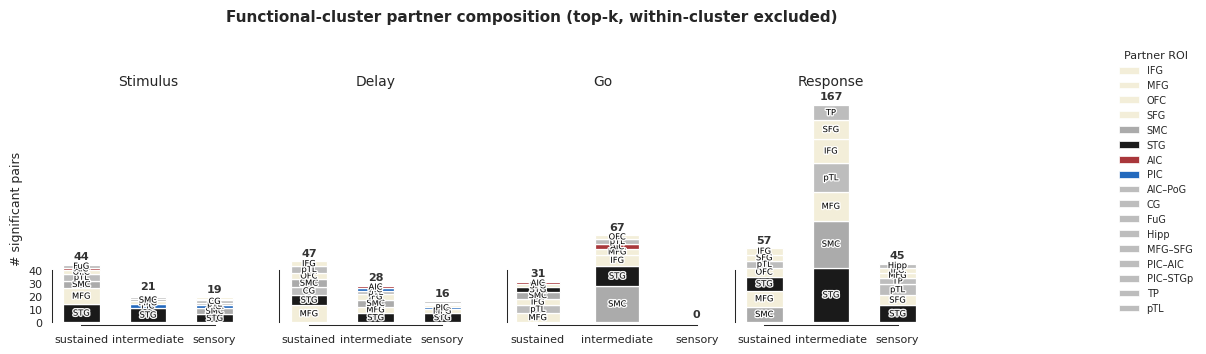

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/connectivity/connectivity_partner_composition.svg


In [8]:
top_k = 7
label_inside_min = 2

df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df.dropna(
    subset=["source_roi", "target_roi", "source_channel", "target_channel", "phase_norm"]
)
df = df[
    (~df["source_roi"].isin(EXCLUDE_ROIS))
    & (~df["target_roi"].isin(EXCLUDE_ROIS))
    & (df["phase_norm"].isin(PHASES))
].copy()

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

rows = []
for focus in FOCUS_CLUSTERS:
    tmp = df[
        (df["source_cluster"] == focus) | (df["target_cluster"] == focus)
    ].copy()
    # drop within-cluster pairs
    tmp = tmp[
        ~((tmp["source_cluster"] == focus) & (tmp["target_cluster"] == focus))
    ].copy()
    if tmp.empty:
        continue
    tmp["focus_cluster"] = focus
    tmp["partner_roi"] = np.where(
        tmp["source_cluster"] == focus, tmp["target_roi"], tmp["source_roi"]
    )
    rows.append(tmp[["phase_norm", "focus_cluster", "partner_roi", "pair_key"]])

if not rows:
    raise RuntimeError("No rows left after filtering for partner composition.")

long_df = pd.concat(rows, ignore_index=True)
agg = (
    long_df.groupby(["phase_norm", "focus_cluster", "partner_roi"], as_index=False)
    .agg(n_pairs=("pair_key", "nunique"))
)

top_chunks = []
for ph in PHASES:
    for focus in FOCUS_CLUSTERS:
        sub = agg[(agg["phase_norm"] == ph) & (agg["focus_cluster"] == focus)].copy()
        if sub.empty:
            continue
        top_chunks.append(sub.sort_values("n_pairs", ascending=False).head(top_k))

top_df = pd.concat(top_chunks, ignore_index=True)
partners = sorted(top_df["partner_roi"].unique())

partner2color = {
    "IFG": "#f3eed9",
    "MFG": "#f3eed9",
    "OFC": "#f3eed9",
    "SFG": "#f3eed9",
    "SMC": "#ababab",
    "STG": "#1A1A1A",
    "STS": "#1A1A1A",
    "Thal": "#2C8DA8",
    "dACC": "#6FB3C8",
    "AIC": red,
    "PIC": blue,
}
for p in partners:
    partner2color.setdefault(p, "#bdbdbd")

sns.set_theme(style="white")
fig, axes = plt.subplots(
    1, len(PHASES),
    figsize=(0.9 * len(FOCUS_CLUSTERS) * len(PHASES), 3.6),
    sharey=True,
)
if len(PHASES) == 1:
    axes = [axes]

focus_ticklabels = [CLUSTER_LABELS[c] for c in FOCUS_CLUSTERS]

for ax, ph in zip(axes, PHASES):
    x_pos = np.arange(len(FOCUS_CLUSTERS), dtype=float)
    bar_width = 0.55
    totals = []

    for i, focus in enumerate(FOCUS_CLUSTERS):
        sub = top_df[
            (top_df["phase_norm"] == ph) & (top_df["focus_cluster"] == focus)
        ].copy()
        bottom = 0
        if sub.empty:
            totals.append(0)
            continue

        for _, r in sub.sort_values("n_pairs", ascending=False).iterrows():
            v = r["n_pairs"]
            p = r["partner_roi"]
            ax.bar(
                x_pos[i], v, width=bar_width, bottom=bottom,
                color=partner2color[p], edgecolor="white", linewidth=0.9,
            )
            if v >= label_inside_min:
                t = ax.text(
                    x_pos[i], bottom + v / 2, p,
                    ha="center", va="center", fontsize=6, fontweight="medium", color="black",
                )
                t.set_path_effects([pe.withStroke(linewidth=2, foreground="white", alpha=0.95)])
            bottom += v
        totals.append(bottom)

    ax.set_title(ph.capitalize(), fontsize=10, fontweight="medium", pad=6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(focus_ticklabels, fontsize=8)
    ax.tick_params(labelsize=8, width=0.8, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
    sns.despine(ax=ax, offset=2, trim=True)
    for i, t in enumerate(totals):
        ax.text(
            x_pos[i], t + 2.5, f"{int(t)}", ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="#333",
        )

axes[0].set_ylabel("# significant pairs", fontsize=9)

legend_order = ["IFG", "MFG", "OFC", "SFG", "SMC", "STG", "STS", "Thal", "dACC", "AIC", "PIC"]
legend_partners = [p for p in legend_order if p in partners] + [
    p for p in partners if p not in legend_order
]
handles = [
    plt.Rectangle((0, 0), 1, 1, color=partner2color[p], ec="white", lw=0.5)
    for p in legend_partners
]
fig.legend(
    handles, legend_partners, title="Partner ROI",
    loc="center right", bbox_to_anchor=(1.12, 0.5),
    ncol=1, frameon=False, fontsize=7, title_fontsize=8,
)
fig.suptitle(
    "Functional-cluster partner composition (top-k, within-cluster excluded)",
    fontsize=11, fontweight="bold", y=0.98,
)
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
plt.show()

save_svg(fig, IMG_DIR / 'connectivity_partner_composition')
print('Saved', IMG_DIR / 'connectivity_partner_composition.svg')


## Phase × partner heatmap

Unique significant pair counts for each NMF focus cluster
(sustained / intermediate / sensory).


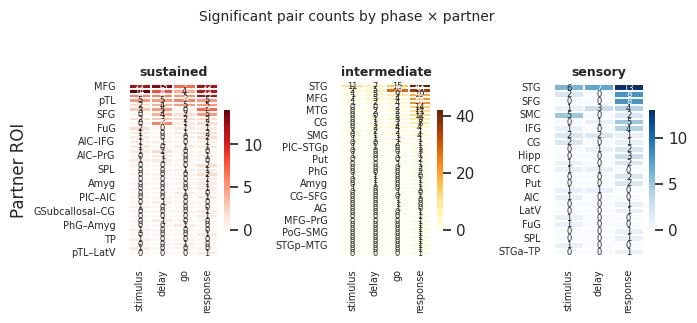

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/connectivity/connectivity_partner_heatmap.svg


In [9]:
n_focus = len(FOCUS_CLUSTERS)
fig, axes = plt.subplots(1, n_focus, figsize=(6 * n_focus * cm, 8 * cm), sharey=False)
if n_focus == 1:
    axes = [axes]

for ax, focus in zip(axes, FOCUS_CLUSTERS):
    sub = agg[agg["focus_cluster"] == focus].copy()
    label = CLUSTER_LABELS[focus]
    if sub.empty:
        ax.set_title(label)
        ax.axis("off")
        continue

    mat = (
        sub.pivot_table(
            index="partner_roi", columns="phase_norm", values="n_pairs", fill_value=0
        )
        .reindex(columns=[p for p in PHASES if p in sub["phase_norm"].unique()], fill_value=0)
    )
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=CLUSTER_CMAPS.get(focus, "Greys"),
        annot=True,
        fmt=".0f",
        annot_kws={"fontsize": 6},
        cbar_kws={"shrink": 0.7},
        linewidths=0.3,
        linecolor="white",
    )
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Partner ROI" if focus == FOCUS_CLUSTERS[0] else "")
    ax.tick_params(labelsize=7)

fig.suptitle("Significant pair counts by phase × partner", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

save_svg(fig, IMG_DIR / 'connectivity_partner_heatmap')
print('Saved', IMG_DIR / 'connectivity_partner_heatmap.svg')


## Lag strip (Delay, sustained)

Each vertical tick is one unique electrode pair (mean lag across tasks).
Positive = focus cluster leads.


Partners: ['pTL', 'STG', 'MFG', 'SMC', 'OFC']
Total pairs: 34


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_546726/2224294310.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))


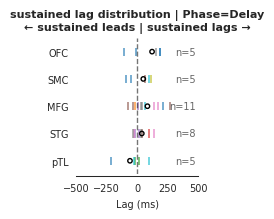

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/connectivity/connectivity_lag_strip_delay_sustained.svg


In [10]:
phase_keep = "delay"
focus_cluster = "sustained_ramping"
focus_label = CLUSTER_LABELS[focus_cluster]
top_k_lag = 5
min_lag_ms = 5

df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

df = df[
    (~df["source_roi"].isin(EXCLUDE_ROIS))
    & (~df["target_roi"].isin(EXCLUDE_ROIS))
    & (df["phase_norm"] == phase_keep)
].copy()

mask = (df["source_cluster"] == focus_cluster) | (df["target_cluster"] == focus_cluster)
df = df[mask].copy()
df = df[
    ~((df["source_cluster"] == focus_cluster) & (df["target_cluster"] == focus_cluster))
].copy()

df["partner_roi"] = np.where(
    df["source_cluster"] == focus_cluster, df["target_roi"], df["source_roi"]
)
df["lag_focus_leads"] = np.where(
    df["source_cluster"] == focus_cluster,
    df["peak_lag_s"],
    -df["peak_lag_s"],
)
df = df[df["lag_focus_leads"].abs() <= MAX_ABS_LAG_S].copy()
df["subject"] = df["source_channel"].str.extract(r"^(D\d+)_")[0]

ab = np.sort(df[["source_channel", "target_channel"]].values, axis=1)
df["pair_key"] = ab[:, 0] + "||" + ab[:, 1]

agg_lag = (
    df.groupby(["partner_roi", "pair_key", "subject"], as_index=False)
    .agg(lag_focus_leads=("lag_focus_leads", "mean"))
)
agg_lag = agg_lag[agg_lag["lag_focus_leads"].abs() >= min_lag_ms / 1000].copy()

partner_counts = agg_lag.groupby("partner_roi").size().sort_values(ascending=False)
top_partners = partner_counts.head(top_k_lag).index.tolist()
agg_lag = agg_lag[agg_lag["partner_roi"].isin(top_partners)].copy()

partner_order = (
    agg_lag.groupby("partner_roi")["lag_focus_leads"].median().sort_values().index.tolist()
)

fig, ax = plt.subplots(figsize=(4 * cm, (0.7 * len(partner_order) + 1) * cm))
subjects = sorted(agg_lag["subject"].dropna().unique())
cmap = plt.cm.get_cmap("tab10", max(len(subjects), 1))
sub_to_color = {s: cmap(i) for i, s in enumerate(subjects)}
partner_to_y = {p: i for i, p in enumerate(partner_order)}

for _, row in agg_lag.iterrows():
    ax.vlines(
        row["lag_focus_leads"] * 1000,
        partner_to_y[row["partner_roi"]] - 0.15,
        partner_to_y[row["partner_roi"]] + 0.15,
        colors=sub_to_color[row["subject"]],
        linewidths=1.2,
        alpha=0.7,
    )

sub_center = (
    agg_lag.groupby(["partner_roi", "subject"], as_index=False)
    .agg(sub_lag=("lag_focus_leads", "median"))
)
center_df = (
    sub_center.groupby("partner_roi", as_index=False)
    .agg(center_lag=("sub_lag", "mean"))
)
for _, r in center_df.iterrows():
    if r["partner_roi"] not in partner_to_y:
        continue
    ax.scatter(
        r["center_lag"] * 1000,
        partner_to_y[r["partner_roi"]],
        s=10, marker="o",
        facecolor="None", edgecolor="black", linewidth=1, zorder=6,
    )

ax.axvline(0, color="k", ls="--", lw=1, alpha=0.6)
ax.set_yticks(range(len(partner_order)))
ax.set_yticklabels(partner_order, fontsize=7)
ax.set_xlabel("Lag (ms)", fontsize=7)
ax.set_xlim(-500, 500)
ax.set_ylim(-0.5, len(partner_order) - 0.5)
ax.tick_params(labelsize=7, width=0.75, length=2)
for spine in ax.spines.values():
    spine.set_linewidth(0.75)

for partner in partner_order:
    n = len(agg_lag[agg_lag["partner_roi"] == partner])
    ax.text(480, partner_to_y[partner], f"n={n}", ha="right", va="center", fontsize=7, color="#666")

ax.set_title(
    (
        f"{focus_label} lag distribution | Phase={phase_keep.capitalize()}"
        + "\n"
        + f"← {focus_label} leads | {focus_label} lags →"
    ),
    fontsize=8, fontweight="bold",
)
sns.despine(ax=ax, left=True, offset=1, trim=True)
ax.tick_params(left=False)

print(f"Partners: {partner_order}")
print(f"Total pairs: {len(agg_lag)}")
plt.show()

save_svg(fig, IMG_DIR / 'connectivity_lag_strip_delay_sustained')
print('Saved', IMG_DIR / 'connectivity_lag_strip_delay_sustained.svg')


## Lag magnitude bins

Fraction of functional-cluster peaks in near-zero / short / long lag bins by phase.


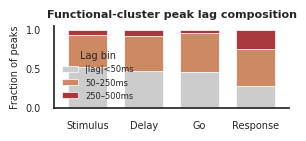

Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/connectivity/connectivity_lag_bins.svg


lag_bin,|lag|<50ms,50–250ms,250–500ms
phase_norm,,,
stimulus,70,56,9
delay,62,57,11
go,66,73,6
response,180,306,156


In [11]:
df = peaks_df.copy()
df["source_roi"] = df["source_roi"].replace(ROI_MAP)
df["target_roi"] = df["target_roi"].replace(ROI_MAP)
df["phase_norm"] = df["phase"].astype(str).str.lower().str.strip()

focus_mask = (
    df["source_cluster"].isin(FOCUS_CLUSTERS)
    | df["target_cluster"].isin(FOCUS_CLUSTERS)
)
df = df[focus_mask & df["phase_norm"].isin(PHASES)].copy()
df = df[
    ~(
        df["source_cluster"].isin(FOCUS_CLUSTERS)
        & df["target_cluster"].isin(FOCUS_CLUSTERS)
    )
].copy()

abs_lag = df["peak_lag_s"].abs()
df["lag_bin"] = pd.cut(
    abs_lag,
    bins=[-np.inf, 0.05, 0.25, np.inf],
    labels=["|lag|<50ms", "50–250ms", "250–500ms"],
)

counts = (
    df.groupby(["phase_norm", "lag_bin"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(PHASES)
    .fillna(0)
)
frac = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(8 * cm, 4 * cm))
frac.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#cccccc", orange, red],
    width=0.7,
    edgecolor="white",
    linewidth=0.5,
)
ax.set_ylabel("Fraction of peaks", fontsize=7)
ax.set_xlabel("")
ax.set_xticklabels([p.capitalize() for p in PHASES], rotation=0, fontsize=7)
ax.tick_params(labelsize=7)
ax.legend(fontsize=6, frameon=False, title="Lag bin", title_fontsize=7)
ax.set_title("Functional-cluster peak lag composition", fontsize=8, fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

save_svg(fig, IMG_DIR / 'connectivity_lag_bins')
print('Saved', IMG_DIR / 'connectivity_lag_bins.svg')

display(counts.astype(int))


## Optional: functional-cluster partner density (brain)

Renders pial partner-density maps for **each phase × {sustained, intermediate, sensory}**
(4 phases × 3 clusters = **12 figures**).
Requires `mne` + `pyvista` and access to `RECON_DIR`. Set `RUN_BRAIN = False`
to skip on a login node without a working 3D backend.



Using notebook 3d backend.
[brain] rendering up to 12 figures (4 phases × 3 clusters)
[brain] Stimulus sustained: pairs=73, focus=29, partners=61


2026-07-28 10:55:24.605 (   1.891s) [    7F72B32E1740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:24.671 (   1.957s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1f217670): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl

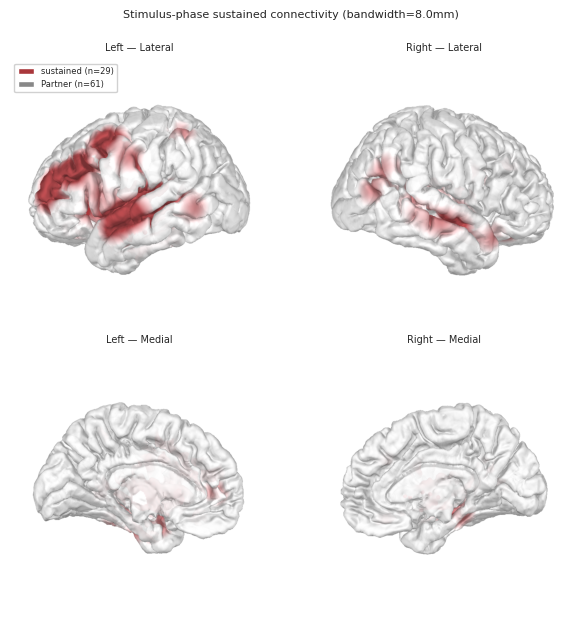

[brain] Stimulus intermediate: pairs=29, focus=13, partners=28


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:29.744 (   7.030s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x47757f70): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

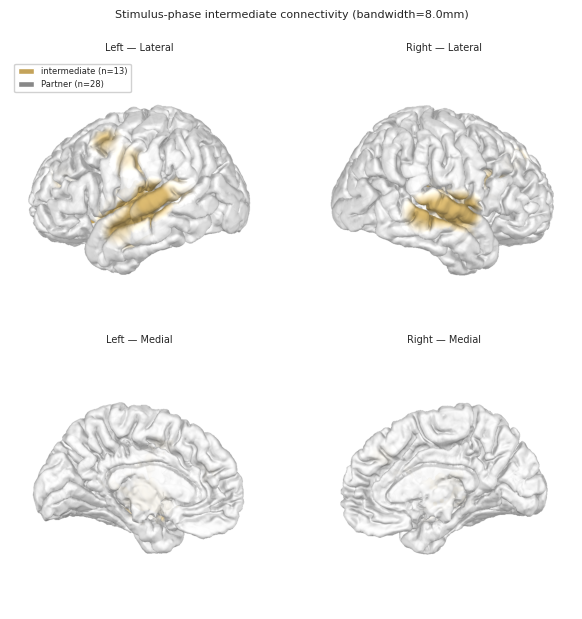

[brain] Stimulus sensory: pairs=49, focus=12, partners=39


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:33.901 (  11.187s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x51abeec0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

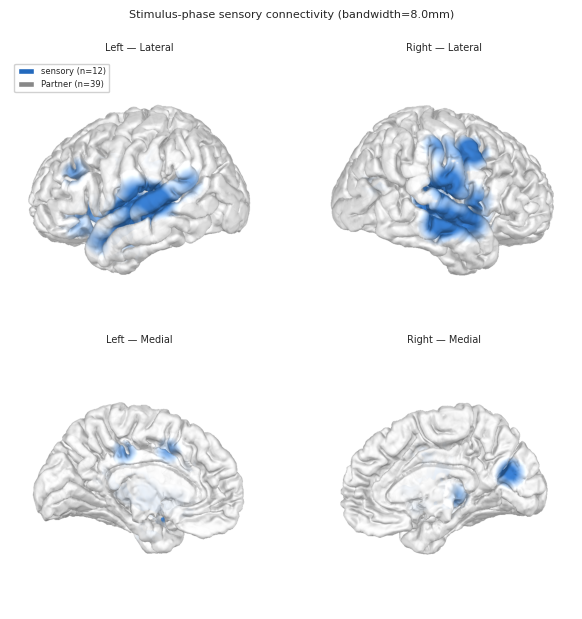

[brain] Delay sustained: pairs=81, focus=30, partners=61


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:38.254 (  15.540s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5c0ca090): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

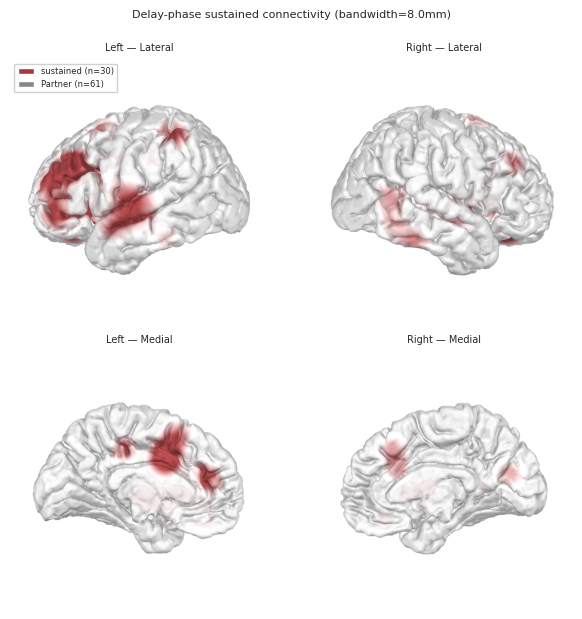

[brain] Delay intermediate: pairs=41, focus=19, partners=41


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:42.391 (  19.677s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x66760310): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

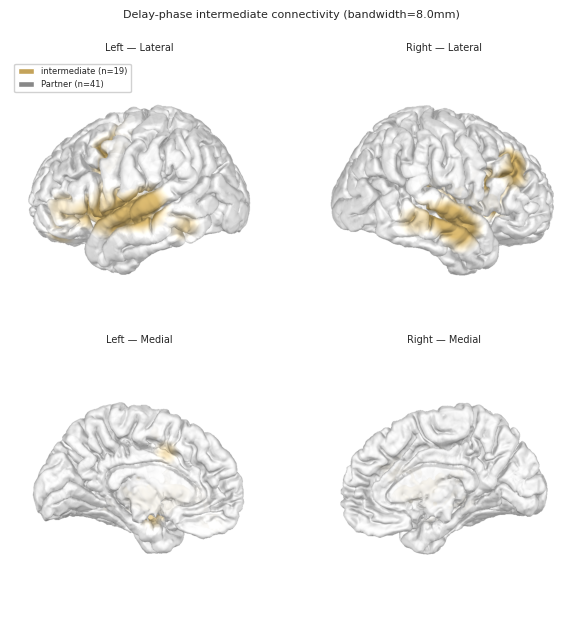

[brain] Delay sensory: pairs=24, focus=9, partners=21


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:51.730 (  29.016s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6458ad10): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

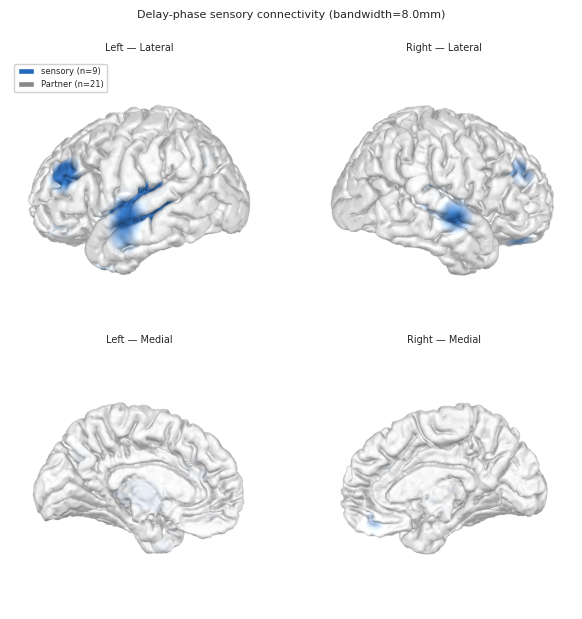

[brain] Go sustained: pairs=45, focus=22, partners=42


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:55:55.984 (  33.270s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x60770c50): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

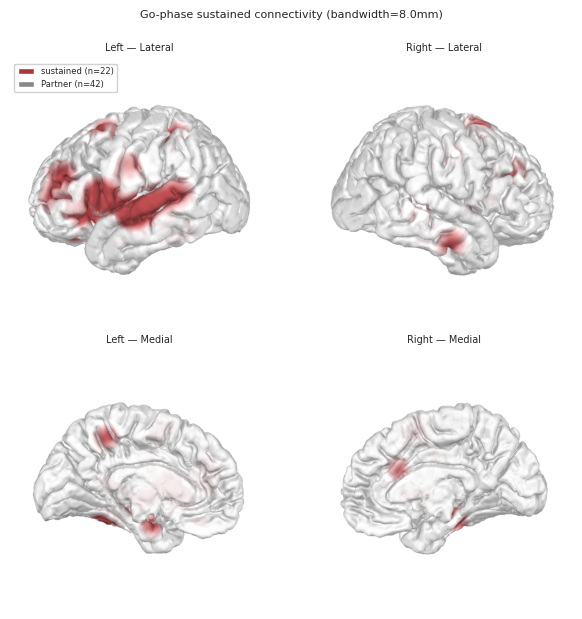

[brain] Go intermediate: pairs=96, focus=36, partners=83


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:00.282 (  37.568s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x4a69e910): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

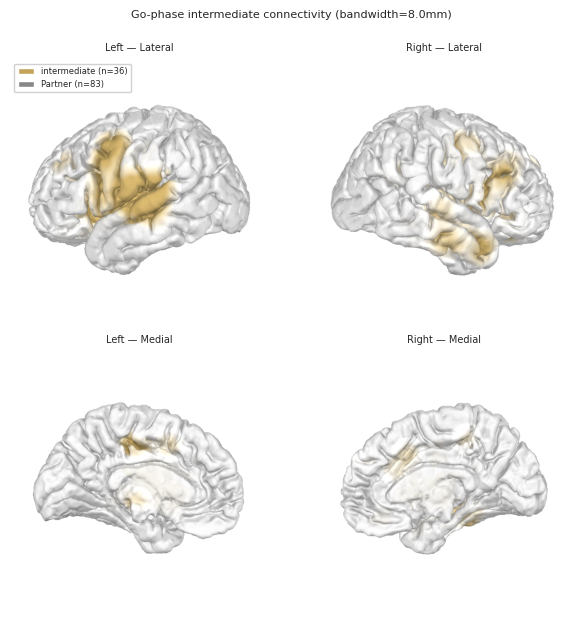

[brain] Go sensory: pairs=10, focus=1, partners=7


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:04.442 (  41.728s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6a0c4cd0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

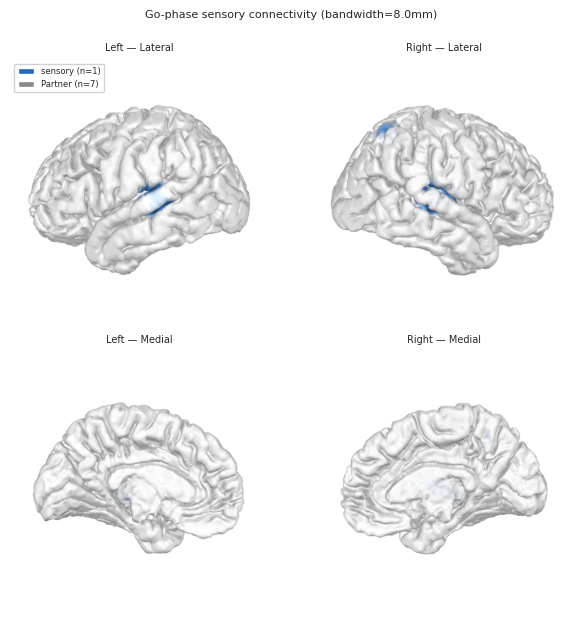

[brain] Response sustained: pairs=95, focus=29, partners=87


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:08.552 (  45.838s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x29d805d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

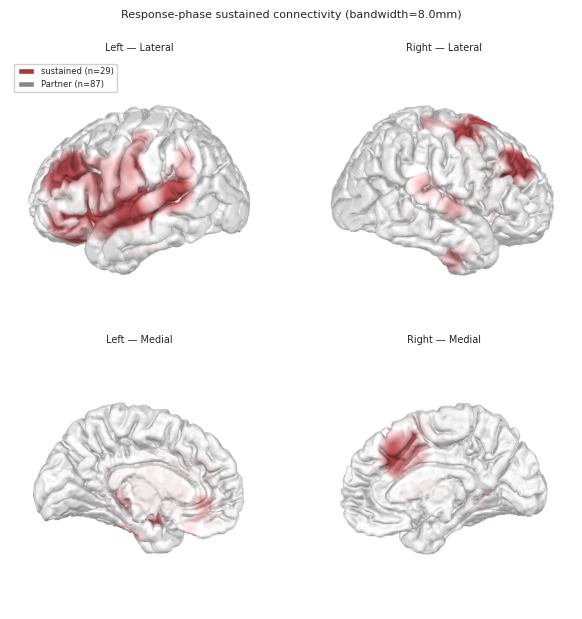

[brain] Response intermediate: pairs=411, focus=60, partners=238


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:13.519 (  50.805s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x88374f40): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

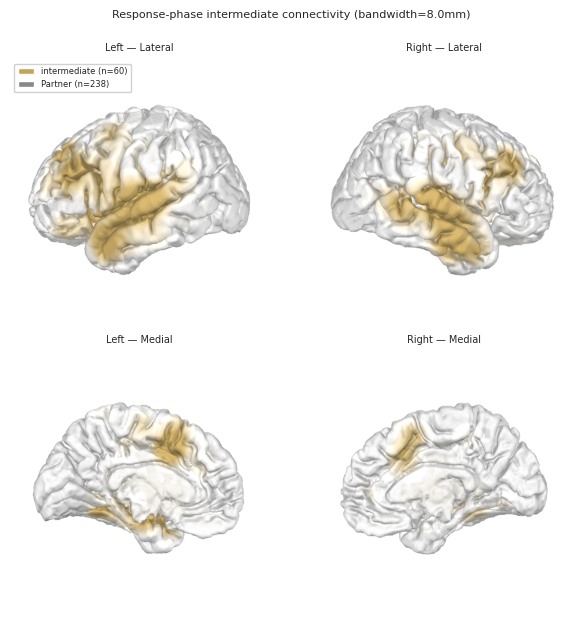

[brain] Response sensory: pairs=209, focus=5, partners=79


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:17.990 (  55.276s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x321f3ce0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

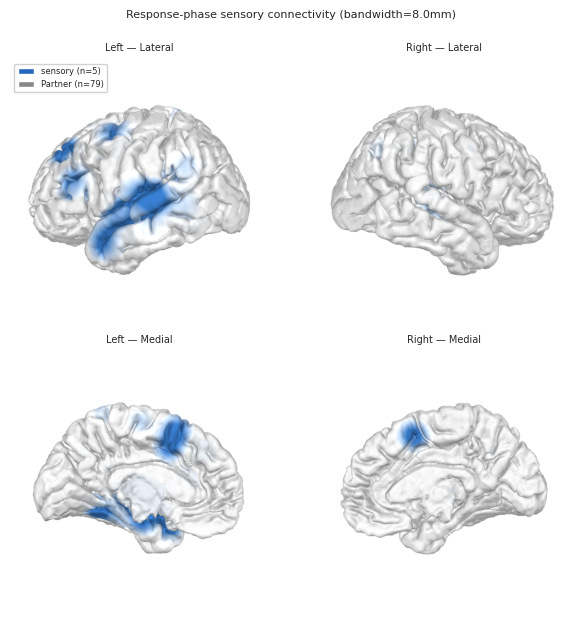

In [12]:
RUN_BRAIN = True  # set False to skip 3D partner-density renders
BRAIN_FOCUS = list(FOCUS_CLUSTERS)
BRAIN_PHASES = ["stimulus", "delay", "go", "response"]  # 4 × 3 = 12 figures

if RUN_BRAIN:
    import mne
    import pyvista as pv
    import matplotlib.colors as mcolors
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    from scipy.spatial import cKDTree
    from scipy.spatial.distance import cdist
    from mne.viz import Brain

    mne.viz.set_3d_backend("notebook")

    lh_pial_coords, _ = mne.read_surface(f"{RECON_DIR}/cvs_avg35_inMNI152/surf/lh.pial")
    rh_pial_coords, _ = mne.read_surface(f"{RECON_DIR}/cvs_avg35_inMNI152/surf/rh.pial")
    lh_tree = cKDTree(lh_pial_coords)
    rh_tree = cKDTree(rh_pial_coords)

    bandwidth = 8.0
    max_distance = 15.0
    n_colors = 256
    coord_lookup = channel_meta.set_index("channel")[["x", "y", "z"]]

    def compute_density(surface_coords, electrode_coords, bandwidth, max_distance):
        if len(electrode_coords) == 0:
            return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
        distances = cdist(surface_coords, electrode_coords)
        mask = distances.min(axis=1) < max_distance
        density = np.exp(-distances**2 / (2 * bandwidth**2)).sum(axis=1)
        density[~mask] = 0
        return density, mask

    def add_electrodes(brain, coords, tree, surf_coords, color, size=14):
        if len(coords) == 0:
            return
        _, idx = tree.query(coords)
        cloud = pv.PolyData(surf_coords[idx])
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=size,
            color=color, lighting=False, smooth_shading=False, opacity=1.0,
        )

    def make_density_cmap(focus_color):
        base = np.array(mcolors.to_rgb(focus_color))
        colors_list = [[1, 1, 1, 0]]
        for i in range(1, n_colors):
            t = i / (n_colors - 1)
            rgb = (1 - t) * np.array([1, 1, 1]) + t * base
            colors_list.append(list(rgb) + [0.9])
        return ListedColormap(colors_list)

    phase_base = sig_roi_df[
        sig_roi_df["source_roi"].notna() & sig_roi_df["target_roi"].notna()
    ].copy()
    phase_base["phase_norm"] = phase_base["phase"].astype(str).str.lower().str.strip()

    n_expected = len(BRAIN_PHASES) * len(BRAIN_FOCUS)
    print(
        f"[brain] rendering up to {n_expected} figures "
        f"({len(BRAIN_PHASES)} phases × {len(BRAIN_FOCUS)} clusters)"
    )

    for phase in BRAIN_PHASES:
        phase_df = phase_base[phase_base["phase_norm"] == phase].copy()

        for focus in BRAIN_FOCUS:
            focus_color = CLUSTER_COLORS.get(focus, red)
            focus_label = CLUSTER_LABELS[focus]
            density_cmap = make_density_cmap(focus_color)

            conn_df = phase_df[
                (phase_df["source_cluster"] == focus)
                ^ (phase_df["target_cluster"] == focus)
            ].copy()
            if conn_df.empty:
                print(f"[brain] {phase.capitalize()} {focus_label}: no significant pairs, skip.")
                continue

            conn_df["focus_channel"] = np.where(
                conn_df["source_cluster"] == focus,
                conn_df["source_channel"],
                conn_df["target_channel"],
            )
            conn_df["partner_channel"] = np.where(
                conn_df["source_cluster"] == focus,
                conn_df["target_channel"],
                conn_df["source_channel"],
            )

            focus_channels = set(conn_df["focus_channel"]) - set(exclude_chn)
            partner_channels = set(conn_df["partner_channel"]) - set(exclude_chn)

            focus_coords = coord_lookup.loc[
                [c for c in focus_channels if c in coord_lookup.index]
            ].values
            partner_coords = coord_lookup.loc[
                [c for c in partner_channels if c in coord_lookup.index]
            ].values

            print(
                f"[brain] {phase.capitalize()} {focus_label}: pairs={len(conn_df)}, "
                f"focus={len(focus_channels)}, partners={len(partner_channels)}"
            )

            mask_focus_lh = focus_coords[:, 0] < 0 if len(focus_coords) else np.array([], dtype=bool)
            mask_focus_rh = focus_coords[:, 0] > 0 if len(focus_coords) else np.array([], dtype=bool)
            mask_par_lh = partner_coords[:, 0] < 0 if len(partner_coords) else np.array([], dtype=bool)
            mask_par_rh = partner_coords[:, 0] > 0 if len(partner_coords) else np.array([], dtype=bool)

            lh_density, lh_dmask = compute_density(
                lh_pial_coords, partner_coords[mask_par_lh], bandwidth, max_distance
            )
            rh_density, rh_dmask = compute_density(
                rh_pial_coords, partner_coords[mask_par_rh], bandwidth, max_distance
            )

            all_valid = np.concatenate([
                lh_density[lh_dmask & (lh_density > 0)],
                rh_density[rh_dmask & (rh_density > 0)],
            ])
            vmin_d = float(np.percentile(all_valid, 10)) if len(all_valid) else 0.0
            vmax_d = float(np.percentile(all_valid, 80)) if len(all_valid) else 1.0

            def render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h):
                brain = Brain(
                    "cvs_avg35_inMNI152", subjects_dir=RECON_DIR, surf="pial", hemi=hemi,
                    background="white", show=False, cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(800, 800),
                )
                data = np.zeros(len(surf_coords))
                has_data = dmask & (density > 0)
                if has_data.any():
                    norm = np.clip((density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1)
                    data[has_data] = 1 + norm * (n_colors - 2)
                brain.add_data(
                    data, hemi=hemi, colormap=density_cmap, alpha=1.0,
                    colorbar=False, fmin=0, fmax=n_colors - 1,
                )
                if focus_mask_h.any():
                    add_electrodes(
                        brain, focus_coords[focus_mask_h], tree, surf_coords,
                        color=focus_color, size=14,
                    )
                brain.show_view(view=view, distance=400)
                return brain

            panels = [
                ("lh", "lateral", lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, "Left — Lateral"),
                ("rh", "lateral", rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, "Right — Lateral"),
                ("lh", "medial", lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, "Left — Medial"),
                ("rh", "medial", rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, "Right — Medial"),
            ]

            screenshots, brains = [], []
            for hemi, view, density, dmask, surf_coords, tree, focus_mask_h, title in panels:
                b = render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h)
                screenshots.append((b.screenshot(mode="rgb"), title))
                brains.append(b)

            fig, axes = plt.subplots(2, 2, figsize=(16 * cm, 16 * cm))
            for ax, (img, title) in zip(axes.flat, screenshots):
                ax.imshow(img)
                ax.axis("off")
                ax.set_title(title, fontsize=fontsize)

            axes[0, 0].legend(
                handles=[
                    Patch(facecolor=focus_color, label=f"{focus_label} (n={len(focus_channels)})"),
                    Patch(facecolor="#888888", label=f"Partner (n={len(partner_channels)})"),
                ],
                loc="upper left", fontsize=fontsize - 1, framealpha=0.9,
            )
            plt.suptitle(
                f"{phase.capitalize()}-phase {focus_label} connectivity "
                f"(bandwidth={bandwidth}mm)",
                fontsize=fontsize + 1,
            )
            for b in brains:
                b.close()
            plt.tight_layout()
            plt.show()
else:
    print("Brain panel skipped (set RUN_BRAIN = True to render).")


## Left-hemisphere partner density (phase grid)

Same partner-density maps as above, but **left lateral only**, arranged as:

| | stimulus | delay | go | response |
|---|---|---|---|---|
| sustained | … | … | … | … |
| intermediate | … | … | … | … |
| sensory | … | … | … | … |



libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:22.538 (  59.824s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5a070440): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

[brain-lh] stimulus sustained: pairs=73, focus_lh=20, partner_lh=45


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:23.609 (  60.895s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x21718a80): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

[brain-lh] delay sustained: pairs=81, focus_lh=23, partner_lh=43


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:24.630 (  61.916s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x78057620): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

...

[brain-lh] delay sensory: pairs=24, focus_lh=7, partner_lh=16


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:32.946 (  70.232s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x47881890): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

[brain-lh] go sensory: pairs=10, focus_lh=0, partner_lh=3


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:56:34.007 (  71.293s) [    7F72B32E1740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x215396d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

[brain-lh] response sensory: pairs=209, focus_lh=4, partner_lh=71


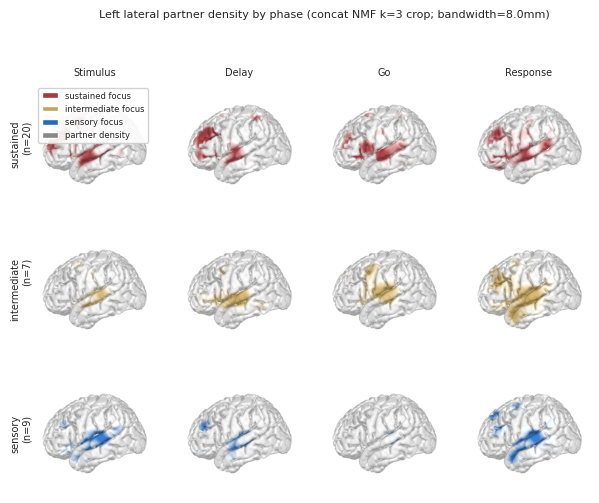

In [13]:
RUN_BRAIN_LH_GRID = True  # set False to skip this panel

if RUN_BRAIN_LH_GRID:
    import mne
    import pyvista as pv
    import matplotlib.colors as mcolors
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    from scipy.spatial import cKDTree
    from scipy.spatial.distance import cdist
    from mne.viz import Brain

    mne.viz.set_3d_backend("notebook")

    # Reuse surfaces from the previous brain cell when available
    if "lh_pial_coords" not in globals() or "lh_tree" not in globals():
        lh_pial_coords, _ = mne.read_surface(
            f"{RECON_DIR}/cvs_avg35_inMNI152/surf/lh.pial"
        )
        lh_tree = cKDTree(lh_pial_coords)

    bandwidth = 8.0
    max_distance = 12.0
    n_colors = 256
    coord_lookup = channel_meta.set_index("channel")[["x", "y", "z"]]

    def _compute_density(surface_coords, electrode_coords, bandwidth, max_distance):
        if len(electrode_coords) == 0:
            return (
                np.zeros(len(surface_coords)),
                np.zeros(len(surface_coords), dtype=bool),
            )
        distances = cdist(surface_coords, electrode_coords)
        mask = distances.min(axis=1) < max_distance
        density = np.exp(-distances**2 / (2 * bandwidth**2)).sum(axis=1)
        density[~mask] = 0
        return density, mask

    def _add_electrodes(brain, coords, tree, surf_coords, color, size=14):
        if len(coords) == 0:
            return
        _, idx = tree.query(coords)
        cloud = pv.PolyData(surf_coords[idx])
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=1.0,
        )

    def _make_density_cmap(focus_color):
        base = np.array(mcolors.to_rgb(focus_color))
        colors_list = [[1, 1, 1, 0]]
        for i in range(1, n_colors):
            t = i / (n_colors - 1)
            rgb = (1 - t) * np.array([1, 1, 1]) + t * base
            colors_list.append(list(rgb) + [0.9])
        return ListedColormap(colors_list)

    def _render_lh_lateral(density, dmask, focus_coords_lh, focus_color, vmin_d, vmax_d, density_cmap):
        brain = Brain(
            "cvs_avg35_inMNI152",
            subjects_dir=RECON_DIR,
            surf="pial",
            hemi="lh",
            background="white",
            show=False,
            cortex=(0.9, 0.9, 0.9),
            alpha=0.9,
            size=(800, 800),
        )
        data = np.zeros(len(lh_pial_coords))
        has_data = dmask & (density > 0)
        if has_data.any():
            norm = np.clip(
                (density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1
            )
            data[has_data] = 1 + norm * (n_colors - 2)
        brain.add_data(
            data,
            hemi="lh",
            colormap=density_cmap,
            alpha=1.0,
            colorbar=False,
            fmin=0,
            fmax=n_colors - 1,
        )
        if len(focus_coords_lh):
            _add_electrodes(
                brain, focus_coords_lh, lh_tree, lh_pial_coords,
                color=focus_color, size=14,
            )
        brain.show_view(view="lateral", distance=400)
        img = brain.screenshot(mode="rgb")
        brain.close()
        return img

    phase_base = sig_roi_df[
        sig_roi_df["source_roi"].notna() & sig_roi_df["target_roi"].notna()
    ].copy()
    phase_base["phase_norm"] = phase_base["phase"].astype(str).str.lower().str.strip()

    grid_phases = ["stimulus", "delay", "go", "response"]
    grid_focus = list(FOCUS_CLUSTERS)  # sustained, intermediate, sensory

    fig, axes = plt.subplots(
        nrows=len(grid_focus),
        ncols=len(grid_phases),
        figsize=(4.2 * len(grid_phases) * cm, 4.5 * len(grid_focus) * cm),
        squeeze=False,
    )

    for row, focus in enumerate(grid_focus):
        focus_color = CLUSTER_COLORS.get(focus, red)
        focus_label = CLUSTER_LABELS[focus]
        density_cmap = _make_density_cmap(focus_color)

        for col, phase in enumerate(grid_phases):
            ax = axes[row, col]
            phase_df = phase_base[phase_base["phase_norm"] == phase].copy()
            conn_df = phase_df[
                (phase_df["source_cluster"] == focus)
                ^ (phase_df["target_cluster"] == focus)
            ].copy()

            if conn_df.empty:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center", color="0.6")
                ax.axis("off")
                if row == 0:
                    ax.set_title(phase.capitalize(), fontsize=fontsize)
                if col == 0:
                    ax.text(
                        -0.02, 0.5, focus_label,
                        transform=ax.transAxes, rotation=90,
                        va="center", ha="right", fontsize=fontsize,
                    )
                continue

            conn_df["focus_channel"] = np.where(
                conn_df["source_cluster"] == focus,
                conn_df["source_channel"],
                conn_df["target_channel"],
            )
            conn_df["partner_channel"] = np.where(
                conn_df["source_cluster"] == focus,
                conn_df["target_channel"],
                conn_df["source_channel"],
            )

            focus_channels = set(conn_df["focus_channel"]) - set(exclude_chn)
            partner_channels = set(conn_df["partner_channel"]) - set(exclude_chn)

            focus_coords = coord_lookup.loc[
                [c for c in focus_channels if c in coord_lookup.index]
            ].values
            partner_coords = coord_lookup.loc[
                [c for c in partner_channels if c in coord_lookup.index]
            ].values

            # Left hemisphere only
            focus_lh = focus_coords[focus_coords[:, 0] < 0] if len(focus_coords) else focus_coords
            partner_lh = (
                partner_coords[partner_coords[:, 0] < 0] if len(partner_coords) else partner_coords
            )

            density, dmask = _compute_density(
                lh_pial_coords, partner_lh, bandwidth, max_distance
            )
            valid = density[dmask & (density > 0)]
            vmin_d = float(np.percentile(valid, 10)) if len(valid) else 0.0
            vmax_d = float(np.percentile(valid, 80)) if len(valid) else 1.0

            img = _render_lh_lateral(
                density, dmask, focus_lh, focus_color, vmin_d, vmax_d, density_cmap
            )
            ax.imshow(img)
            ax.axis("off")
            if row == 0:
                ax.set_title(phase.capitalize(), fontsize=fontsize)
            if col == 0:
                ax.text(
                    -0.02, 0.5,
                    f"{focus_label}\n(n={len(focus_lh)})",
                    transform=ax.transAxes, rotation=90,
                    va="center", ha="right", fontsize=fontsize,
                )
            print(
                f"[brain-lh] {phase} {focus_label}: "
                f"pairs={len(conn_df)}, focus_lh={len(focus_lh)}, partner_lh={len(partner_lh)}"
            )

    axes[0, 0].legend(
        handles=[
            Patch(
                facecolor=CLUSTER_COLORS[c],
                label=f"{CLUSTER_LABELS[c]} focus",
            )
            for c in FOCUS_CLUSTERS
        ]
        + [Patch(facecolor="#888888", label="partner density")],
        loc="upper left",
        fontsize=fontsize - 1,
        framealpha=0.9,
    )
    fig.suptitle(
        f"Left lateral partner density by phase "
        f"(concat NMF k=3 crop; bandwidth={bandwidth}mm)",
        fontsize=fontsize + 1,
        y=1.02,
    )
    fig.subplots_adjust(left=0.06)
    # save
    plt.savefig(IMG_DIR / 'connectivity_lh_grid.svg', bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("Left-hemisphere grid skipped (set RUN_BRAIN_LH_GRID = True to render).")
